<a href="https://colab.research.google.com/github/Sanskar-cpu-sudo/Deep-Learning/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This assignment implements forward propagation and backpropagation using TensorFlow/Keras on the Wine dataset.
# It analyzes the effect of different learning rates and epochs on model performance.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
wine = load_wine()
X = wine.data
y = wine.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=10, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def create_model(learning_rate):
    model = Sequential([
        Dense(16, activation='relu', input_shape=(13,)),
        Dense(12, activation='relu'),
        Dense(3, activation='softmax')
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
learning_rates = [0.0005, 0.001, 0.01]
epochs_list = [5,7,9]

In [ ]:
results = {}

In [ ]:
for lr in learning_rates:
    for epochs in epochs_list:

        print(f"\nLearning Rate = {lr}, Epochs = {epochs}")

        model = create_model(lr)

        history = model.fit(
            X_train,
            y_train,
            epochs=epochs,
            validation_split=0.2,
            verbose=0
        )

        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

        results[(lr, epochs)] = {
            "accuracy": accuracy,
            "history": history.history
        }

        print("Test Accuracy:", round(accuracy, 4))


Learning Rate = 0.0005, Epochs = 5


In [ ]:
history = results[(0.001, 7)]["history"]


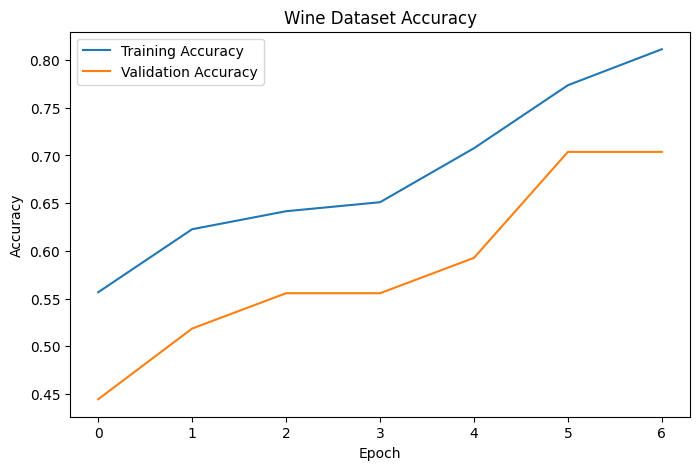

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Wine Dataset Accuracy")
plt.legend()
plt.show()

In [ ]:
print("\nPerformance Summary")
print("----------------------------------------------")
print("Learning Rate\tEpochs\tAccuracy")
print("----------------------------------------------")

for key, value in results.items():
    print(f"{key[0]}\t\t{key[1]}\t{value['accuracy']:.4f}")


Performance Summary
----------------------------------------------
Learning Rate	Epochs	Accuracy
----------------------------------------------
0.0005		5	0.6000
0.0005		7	0.3333
0.0005		9	0.6889
0.001		5	0.4444
0.001		7	0.8444
0.001		9	0.6667
0.01		5	0.9778
0.01		7	0.9778
0.01		9	1.0000
